# **Mount Drive**

In [ ]:

# out_path = '<DATA_ROOT>/Final_Exports/20231121-Section3/'
# plt.savefig(out_path + 'HeatMap_HeatWave_Thr_Yield_Decrease' + '.png' , dpi=1200)

# **Load Data**

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)



In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import detrend

fpath_yield = '<DATA_ROOT>/Yield/crops_us_yield_agg_irig.csv'
dfy = pd.read_csv(fpath_yield)
df_grouped = dfy.groupby(['state_name','county_name','prodn_practice_desc','commodity_desc'])

def detrend_yield(yield_series):
    detrended_yield = detrend(yield_series)
    return pd.Series(detrended_yield, index=yield_series.index)

dfy['detrended_yield'] = df_grouped['value_yield'].transform(detrend_yield)

fpath_fips = '<DATA_ROOT>/Yield/yield_fips_code.csv'
dffipsy = pd.read_csv(fpath_fips).rename(columns={' county_code':'county_code'})
df_new = dffipsy.copy()
formatted_numbers = [str(n).zfill(3) for n in df_new['county_code'].values]
df_new['county_code'] = formatted_numbers
formatted_numbers = [str(n).zfill(2) for n in df_new['state_fips_code'].values]
df_new['state_fips_code'] = formatted_numbers
df_new['FIPS'] = df_new['state_fips_code'] + df_new['county_code']
dffipsy = df_new
dffipsy = dffipsy.drop(columns=['state_fips_code' , 'county_code'])
dffipsy

dfy = pd.merge(dfy,dffipsy,on=['state_name', 'county_name'])
dfy.iloc[0:5]

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])
# cond1 = df_fail['year']>2011
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2]
df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
df_fail = df_fail[df_fail.fail_share > 0]

formatted_numbers = [str(n).zfill(5) for n in df_fail['FIPS'].values]
df_fail['FIPS'] = formatted_numbers

# df_fail.year.unique()

In [ ]:
fsvi = '<DATA_ROOT>/SVI/SVI_timeseries.csv'
df_svi = pd.read_csv(fsvi)
df_svi = df_svi.sort_values(by=['FIPS'])
formatted_numbers = [str(n).zfill(5) for n in df_svi['FIPS'].values]
df_svi['FIPS'] = formatted_numbers
df_svi.iloc[0:5,:]

In [ ]:
fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
dft = pd.read_csv(fpath1)
dft = dft.rename(columns={'Year':'year'})
formatted_numbers = [str(n).zfill(5) for n in dft['FIPS'].values]
dft['FIPS'] = formatted_numbers
dft.iloc[0:2,:]

# fpath2 = '<DATA_ROOT>/WeatherIndex/Drought_Map.csv'
# dfd = pd.read_csv(fpath2)
# dfd = dfd.rename(columns={'Year':'year', 'STATE':'State', 'COUNTY':'County'})
# fpath = '<DATA_ROOT>/WeatherIndex/svi2020fips.csv'
# df_fips_obj = pd.read_csv(fpath)[['FIPS',	'OBJECTID']]
# dfd = pd.merge(dfd,df_fips_obj,on=['OBJECTID'])
# formatted_numbers = [str(n).zfill(5) for n in dfd['FIPS'].values]
# dfd['FIPS'] = formatted_numbers
# print(dfd.iloc[0:2,:])

In [ ]:
# drought_indices = ['PDSI', 'SPEI3', 'SPEI6', 'SPEI9', 'SPEI12', 'SPI3', 'SPI6', 'SPI9', 'SPI12']
# for idx in drought_indices:
#   dfd.loc[dfd[idx] == 0,idx] = 1
# print(dfd.iloc[0:2,:])

HW_indices = ['Thr26', 'Thr27', 'Thr28', 'Thr29', 'Thr30', 'Thr31', 'Thr32', 'Thr33', 'Thr34', 'Thr35', 'Thr36']
for idx in HW_indices:
  dft.loc[dft[idx] == 0,idx] = 1
print(dft.iloc[0:2,:])


In [ ]:
shp_counties = '<DATA_ROOT>/SVI/Counties/'
counties = gpd.read_file(shp_counties)
# formatted_numbers = [int(n) for n in counties['FIPS'].values]
# counties['FIPS'] = formatted_numbers
counties.iloc[0:5,:]

In [ ]:
ClimReg_dir = '<DATA_ROOT>/US_ClimateRegions/US_ClimateRegions/'
gdf_clim = gpd.read_file(ClimReg_dir)
gdf_clim

In [ ]:
# import zipfile
# zip_path = '<DATA_ROOT>/CONUS_States/CONUS_STATES.zip'
# extract_dir = '<DATA_ROOT>/CONUS_States/'
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

In [ ]:
states_dir = '<DATA_ROOT>/CONUS_States/'
gdf_states = gpd.read_file(states_dir)
gdf_states

# **HeatMap HeatWave**

In [23]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

**HeatMap HeatWave Failure**

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])

cond1 = df_fail['Irrigation Practice'] == 'ALL'
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2 & cond1]

df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
df_fail = df_fail[df_fail.fail_share > 0]

formatted_numbers = [str(n).zfill(5) for n in df_fail['FIPS'].values]
df_fail.loc[:,'FIPS'] = formatted_numbers

cols = ['FIPS', 'Crop', 'Planted Acres', 'year', 'fail_share']
df_fail = df_fail[cols]
# df_fail.iloc[0:2,:]

In [25]:
fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
dft = pd.read_csv(fpath1)
dft = dft.rename(columns={'Year':'year'})
formatted_numbers = [str(n).zfill(5) for n in dft['FIPS'].values]
dft.loc[:,'FIPS'] = formatted_numbers
dft = dft.drop(columns=['State',	'County']).set_index(['FIPS', 'year'])
dft[dft == 0] = np.nan
# dft.iloc[0:2,:]

In [26]:
df_merge = pd.merge(df_fail[['FIPS','Crop','year','fail_share']],dft.reset_index(),on=['FIPS','year'])
HW_thrs = list(dft.columns)
df_num_eve_thr = pd.DataFrame(columns=['Crop','HW_noHW']+HW_thrs)
df_num_eve_thr.Crop = sorted(list(df_merge.Crop.unique()) * 2)
df_num_eve_thr.HW_noHW = [1,-1] * 8
df_num_eve_thr = df_num_eve_thr.set_index(['Crop','HW_noHW'])

def get_num_events(df_merge , thr):
  df_group = df_merge.groupby(['Crop',thr]).count().reset_index()
  df_group = df_group[['Crop',thr,'FIPS']].rename(columns={'FIPS':thr,thr:'HW_noHW'})
  df_group = df_group.set_index(['Crop','HW_noHW'])
  return df_group

for thr in HW_thrs:
  df_num_eve_thr[thr] = get_num_events(df_merge , thr)

df_num_eve_thr = df_num_eve_thr.reset_index()
df_num_eve_thr_HW = df_num_eve_thr[df_num_eve_thr['HW_noHW']==1].set_index('Crop')
df_num_eve_thr_noHW = df_num_eve_thr[df_num_eve_thr['HW_noHW']==-1].set_index('Crop')
df_ratio_HWnoHW = df_num_eve_thr_noHW / df_num_eve_thr_HW
df_ratio_HWnoHW = df_ratio_HWnoHW.drop(columns={'HW_noHW'})

In [27]:
fig , axes = plt.subplots(figsize=(10,6) , dpi=1200)
sns.heatmap(df_ratio_HWnoHW, cmap='Reds_r',vmax=0.45,vmin=0)
out_path = '<DATA_ROOT>/Final_Exports/20231121-Section3/'
plt.savefig(out_path + 'HeatMap_HeatWave_Failure_Count_Ratio' + '.png' , dpi=1200)

**HeatMap HeatWave Yeild Decrease**

In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import detrend

fpath_yield = '<DATA_ROOT>/Yield/crops_us_yield_agg_irig.csv'
dfy = pd.read_csv(fpath_yield)
df_grouped = dfy.groupby(['state_name','county_name','prodn_practice_desc','commodity_desc'])

def detrend_yield(yield_series):
    detrended_yield = detrend(yield_series)
    return pd.Series(detrended_yield, index=yield_series.index)

dfy['detrended_yield'] = df_grouped['value_yield'].transform(detrend_yield)

fpath_fips = '<DATA_ROOT>/Yield/yield_fips_code.csv'
dffipsy = pd.read_csv(fpath_fips).rename(columns={' county_code':'county_code'})
df_new = dffipsy.copy()
formatted_numbers = [str(n).zfill(3) for n in df_new['county_code'].values]
df_new['county_code'] = formatted_numbers
formatted_numbers = [str(n).zfill(2) for n in df_new['state_fips_code'].values]
df_new['state_fips_code'] = formatted_numbers
df_new['FIPS'] = df_new['state_fips_code'] + df_new['county_code']
dffipsy = df_new
dffipsy = dffipsy.drop(columns=['state_fips_code' , 'county_code'])
dffipsy

dfy = pd.merge(dfy,dffipsy,on=['state_name', 'county_name'])
dfy.iloc[0:5]

In [ ]:
cond_ig = dfy['prodn_practice_desc'] == 'ALL PRODUCTION PRACTICES'
cond_year = dfy['year'] > 2008
yield_cols = ['FIPS', 'year','commodity_desc', 'detrended_yield']
dfy = dfy[yield_cols][cond_ig & cond_year]
dfy = dfy.sort_values(['FIPS', 'commodity_desc', 'year'])

def cal_change(group):
    return group.diff()

dfy['diff_yield'] = dfy.groupby(['FIPS', 'commodity_desc'])['detrended_yield'].transform(cal_change)
dfy


In [30]:
fpath1 = '<DATA_ROOT>/WeatherIndex/Temp_Tercile_11nov.csv'
dft = pd.read_csv(fpath1)
dft = dft.rename(columns={'Year':'year'})
formatted_numbers = [str(n).zfill(5) for n in dft['FIPS'].values]
dft.loc[:,'FIPS'] = formatted_numbers
dft = dft.drop(columns=['State',	'County']).set_index(['FIPS', 'year'])
dft[dft == 0] = np.nan
# dft.iloc[0:2,:]

In [31]:
dfy = dfy.rename(columns={'commodity_desc':'Crop'})
cond_decrease = dfy['diff_yield'] < 0
df_merge = pd.merge(dfy.loc[cond_decrease,['FIPS','Crop','year','diff_yield']],
                    dft.reset_index(),on=['FIPS','year'])
HW_thrs = list(dft.columns)
df_num_eve_thr = pd.DataFrame(columns=['Crop','HW_noHW']+HW_thrs)
df_num_eve_thr.Crop = sorted(list(df_merge.Crop.unique()) * 2)
df_num_eve_thr.HW_noHW = [1,-1] * 8
df_num_eve_thr = df_num_eve_thr.set_index(['Crop','HW_noHW'])

def get_num_events(df_merge , thr):
  df_group = df_merge.groupby(['Crop',thr]).count().reset_index()
  df_group = df_group[['Crop',thr,'FIPS']].rename(columns={'FIPS':thr,thr:'HW_noHW'})
  df_group = df_group.set_index(['Crop','HW_noHW'])
  return df_group

for thr in HW_thrs:
  df_num_eve_thr[thr] = get_num_events(df_merge , thr)

df_num_eve_thr = df_num_eve_thr.reset_index()
df_num_eve_thr_HW = df_num_eve_thr[df_num_eve_thr['HW_noHW']==1].set_index('Crop')
df_num_eve_thr_noHW = df_num_eve_thr[df_num_eve_thr['HW_noHW']==-1].set_index('Crop')
df_ratio_HWnoHW = df_num_eve_thr_noHW / df_num_eve_thr_HW
df_ratio_HWnoHW = df_ratio_HWnoHW.drop(columns={'HW_noHW'})

In [32]:
fig , axes = plt.subplots(figsize=(10,6) , dpi=1200)
sns.heatmap(df_ratio_HWnoHW, cmap='Reds_r',vmax=0.45,vmin=0)
out_path = '<DATA_ROOT>/Final_Exports/20231121-Section3/'
plt.savefig(out_path + 'HeatMap_HeatWave_Yeild_Decrease_Ratio' + '.png' , dpi=1200)

# **HeatMap SPI**

In [33]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
from matplotlib import pyplot as plt
import seaborn as sns
from glob import glob

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

**HeatMap SPI-Drought Failure**

In [ ]:
ffail = '<DATA_ROOT>/crop_failure_data/crops_failure_0595.csv'
df_fail = pd.read_csv(ffail)
df_fail = df_fail.drop(columns=['Unnamed: 0'])
df_fail = df_fail.sort_values(by=['FIPS'])

cond1 = df_fail['Irrigation Practice'] == 'ALL'
cond2 = df_fail['Planted Acres'] > 0
df_fail = df_fail[cond2 & cond1]

df_fail['fail_share'] = df_fail['Failed Acres'] /  df_fail['Planted Acres']
df_fail = df_fail[df_fail.fail_share < 1]
df_fail = df_fail[df_fail.fail_share > 0]
df_fail.loc[:,'fail_event'] = (df_fail.fail_share > 0).astype(int)

formatted_numbers = [str(n).zfill(5) for n in df_fail['FIPS'].values]
df_fail.loc[:,'FIPS'] = formatted_numbers

cols = ['FIPS', 'Crop', 'year', 'fail_share', 'fail_event']
df_fail = df_fail[cols]
# df_fail.iloc[0:2,:]

In [56]:
gdf = gpd.read_file('<DATA_ROOT>/WeatherIndex/SVI_2020/SVI_2020.shp')
drt = xr.open_dataset('<DATA_ROOT>/WeatherIndex/list_drought14.nc')
idx = 5
drt = drt.isel(indices=idx)
list_idx = ['spei14d','spei30d','spei90d','spi14d','spi30d','spi90d']
dr_index = list_idx[idx]

In [57]:
def get_drought_fails(th):
  drt_th = xr.where(drt.spei14d < th , 1 , 0)
  drt_th = drt_th.groupby(drt_th.time.dt.year).sum()
  quant = drt_th.quantile(q=[0.33,0.66],dim='year')

  ds_noDr = drt_th.where( drt_th  <= quant[0] , drop=True)
  ds_noDr = ds_noDr.where( ds_noDr.year  > 2008 , drop=True)
  df_noDr = ds_noDr.to_dataframe().reset_index()
  df_noDr = pd.merge(df_noDr[['county','year','spei14d']],gdf[['OBJECTID','FIPS']],
                      left_on='county',right_on='OBJECTID').drop(columns=['county','OBJECTID'])
  df_noDr = df_noDr.dropna()
  df_noDr['spei14d'] = -1

  ds_Dr = drt_th.where( drt_th  >= quant[1] , drop=True)
  ds_Dr = ds_Dr.where( ds_Dr.year  > 2008 , drop=True)
  df_Dr = ds_Dr.to_dataframe().reset_index()
  df_Dr = pd.merge(df_Dr[['county','year','spei14d']],gdf[['OBJECTID','FIPS']],
                      left_on='county',right_on='OBJECTID').drop(columns=['county','OBJECTID'])
  df_Dr = df_Dr.dropna()
  df_Dr['spei14d'] = 1

  df_Dr_noDr = pd.concat([df_Dr,df_noDr],axis=0)

  df_merge = pd.merge(df_fail[['FIPS','year','Crop','fail_share','fail_event']],df_Dr_noDr,on=['FIPS','year'])
  df_merge = df_merge.rename(columns={'spei14d':'Dr_noDr'})
  df_group = df_merge.groupby(['Crop','Dr_noDr']).agg({'fail_event':'sum'})#,'fail_share':'mean'
  df_group.columns = [str(th)]
  return df_group


In [58]:
list_df = []
for th in np.arange(-2,0.1,0.25):
  df_group_th = get_drought_fails(th)
  list_df.append(df_group_th)

df = pd.concat(list_df,axis=1).reset_index()
df_Dr = df[df.Dr_noDr==1].drop(columns=['Dr_noDr']).set_index(['Crop'])
df_noDr = df[df.Dr_noDr==-1].drop(columns=['Dr_noDr']).set_index(['Crop'])
df_ratio_Dr_noDr = df_noDr / df_Dr
df_ratio_Dr_noDr

,-2.0,-1.75,-1.5,-1.25,-1.0,-0.75,-0.5,-0.25,0.0
Crop,,,,,,,,,
BARLEY,0.921708,1.408759,1.261682,1.161905,1.260417,1.242424,1.113208,1.180952,1.151786
CORN,1.022312,1.506080,1.489562,1.497985,1.719536,1.823371,1.937893,2.033075,2.200900
COTTON,0.843077,1.076261,0.990950,0.988746,1.007030,1.131970,1.178236,1.238185,1.257198
HAY,0.924312,1.461712,1.454810,1.462541,1.440789,1.572993,1.582734,1.602941,1.664234
OATS,0.743925,0.977987,0.890566,0.889796,0.867769,0.914530,0.851695,0.826613,0.863071
SORGHUM,0.848881,0.997238,0.803077,0.795455,0.806228,0.837370,0.856655,0.880952,0.967972
SOYBEANS,1.029451,1.552695,1.462525,1.498901,1.635824,1.739899,1.885827,1.952639,2.129496
WHEAT,0.940609,1.458733,1.331876,1.292984,1.380694,1.419647,1.479066,1.489877,1.543597


In [59]:
fig , axes = plt.subplots(figsize=(10,6) , dpi=1200)
sns.heatmap(df_ratio_Dr_noDr, cmap='Reds_r',vmax=1.2,vmin=0.2)
out_path = '<DATA_ROOT>/Final_Exports/20231121-Section3/20231202-HeatMap_SPI_Thr_Failure/'
plt.savefig(out_path + f'HeatMap_{dr_index}_Failure_Count_Ratio' + '.png' , dpi=1200)

**HeatMap SPI-Drought Yeild Decrease**

In [60]:
import pandas as pd
import numpy as np
from scipy.signal import detrend

fpath_yield = '<DATA_ROOT>/Yield/crops_us_yield_agg_irig.csv'
dfy = pd.read_csv(fpath_yield)
df_grouped = dfy.groupby(['state_name','county_name','prodn_practice_desc','commodity_desc'])

def detrend_yield(yield_series):
    detrended_yield = detrend(yield_series)
    return pd.Series(detrended_yield, index=yield_series.index)

dfy['detrended_yield'] = df_grouped['value_yield'].transform(detrend_yield)

fpath_fips = '<DATA_ROOT>/Yield/yield_fips_code.csv'
dffipsy = pd.read_csv(fpath_fips).rename(columns={' county_code':'county_code'})
df_new = dffipsy.copy()
formatted_numbers = [str(n).zfill(3) for n in df_new['county_code'].values]
df_new['county_code'] = formatted_numbers
formatted_numbers = [str(n).zfill(2) for n in df_new['state_fips_code'].values]
df_new['state_fips_code'] = formatted_numbers
df_new['FIPS'] = df_new['state_fips_code'] + df_new['county_code']
dffipsy = df_new
dffipsy = dffipsy.drop(columns=['state_fips_code' , 'county_code'])
dffipsy

dfy = pd.merge(dfy,dffipsy,on=['state_name', 'county_name'])
cond_ig = dfy['prodn_practice_desc'] == 'ALL PRODUCTION PRACTICES'
cond_year = dfy['year'] > 2008
yield_cols = ['FIPS', 'year','commodity_desc', 'detrended_yield']
dfy = dfy[yield_cols][cond_ig & cond_year]
dfy = dfy.rename(columns={'commodity_desc':'Crop'})
dfy = dfy.sort_values(['FIPS', 'Crop', 'year'])

def cal_change(group):
    return group.diff()

dfy['diff_yield'] = dfy.groupby(['FIPS', 'Crop'])['detrended_yield'].transform(cal_change)
cond_decrease = dfy['diff_yield'] < 0
dfy = dfy[cond_decrease]
dfy.iloc[0:5]

,FIPS,year,Crop,detrended_yield,diff_yield
892360,01001,2013,CORN,0.203564,-0.333763
892362,01001,2018,CORN,1.819497,-0.166123
892363,01001,2019,CORN,1.785454,-0.034043
892364,01001,2020,CORN,1.522810,-0.262643
892427,01001,2013,COTTON,0.024866,-0.219866


In [81]:
gdf = gpd.read_file('<DATA_ROOT>/WeatherIndex/SVI_2020/SVI_2020.shp')
drt = xr.open_dataset('<DATA_ROOT>/WeatherIndex/list_drought14.nc')
idx = 5
drt = drt.isel(indices=idx)
list_idx = ['spei14d','spei30d','spei90d','spi14d','spi30d','spi90d']
dr_index = list_idx[idx]

In [82]:
def get_drought_fails(th):
  drt_th = xr.where(drt.spei14d < th , 1 , 0)
  drt_th = drt_th.groupby(drt_th.time.dt.year).sum()
  quant = drt_th.quantile(q=[0.33,0.66],dim='year')

  ds_noDr = drt_th.where( drt_th  <= quant[0] , drop=True)
  ds_noDr = ds_noDr.where( ds_noDr.year  > 2008 , drop=True)
  df_noDr = ds_noDr.to_dataframe().reset_index()
  df_noDr = pd.merge(df_noDr[['county','year','spei14d']],gdf[['OBJECTID','FIPS']],
                      left_on='county',right_on='OBJECTID').drop(columns=['county','OBJECTID'])
  df_noDr = df_noDr.dropna()
  df_noDr['spei14d'] = -1

  ds_Dr = drt_th.where( drt_th  >= quant[1] , drop=True)
  ds_Dr = ds_Dr.where( ds_Dr.year  > 2008 , drop=True)
  df_Dr = ds_Dr.to_dataframe().reset_index()
  df_Dr = pd.merge(df_Dr[['county','year','spei14d']],gdf[['OBJECTID','FIPS']],
                      left_on='county',right_on='OBJECTID').drop(columns=['county','OBJECTID'])
  df_Dr = df_Dr.dropna()
  df_Dr['spei14d'] = 1

  df_Dr_noDr = pd.concat([df_Dr,df_noDr],axis=0)

  df_merge = pd.merge(dfy[['FIPS','year','Crop','diff_yield']],df_Dr_noDr,on=['FIPS','year'])
  df_merge = df_merge.rename(columns={'spei14d':'Dr_noDr'})
  df_group = df_merge.groupby(['Crop','Dr_noDr']).agg({'diff_yield':'count'})#,'fail_share':'mean'
  df_group.columns = [str(th)]
  return df_group


In [83]:
list_df = []
for th in np.arange(-2,0.1,0.25):
  df_group_th = get_drought_fails(th)
  list_df.append(df_group_th)

df = pd.concat(list_df,axis=1).reset_index()
df_Dr = df[df.Dr_noDr==1].drop(columns=['Dr_noDr']).set_index(['Crop'])
df_noDr = df[df.Dr_noDr==-1].drop(columns=['Dr_noDr']).set_index(['Crop'])
df_ratio_Dr_noDr = df_noDr / df_Dr
df_ratio_Dr_noDr

,-2.0,-1.75,-1.5,-1.25,-1.0,-0.75,-0.5,-0.25,0.0
Crop,,,,,,,,,
BARLEY,0.832884,1.241026,1.118750,0.990415,1.006601,1.074324,1.081633,1.182796,1.190813
CORN,0.876077,1.215421,1.086779,1.021121,1.087830,1.144729,1.197926,1.248610,1.301757
COTTON,0.924983,1.268817,1.172662,1.176287,1.256993,1.315603,1.323478,1.390764,1.452899
HAY,0.834240,1.157558,0.977456,0.883910,0.919009,0.943879,0.968345,0.987900,0.991321
OATS,0.866109,1.337472,1.362687,1.341463,1.397611,1.530275,1.631478,1.854167,1.939076
SORGHUM,0.764774,0.875666,0.668627,0.582178,0.554192,0.540434,0.547244,0.518375,0.517375
SOYBEANS,0.856759,1.184177,1.049141,0.991964,1.065074,1.144009,1.209118,1.262333,1.337214
WHEAT,0.882999,1.259038,1.108233,1.043425,1.122662,1.162427,1.250924,1.309839,1.317505


In [84]:
fig , axes = plt.subplots(figsize=(10,8) , dpi=1200)
sns.heatmap(df_ratio_Dr_noDr,cmap='Reds_r',vmax=1.25,vmin=0.2)
out_path = '<DATA_ROOT>/Final_Exports/20231121-Section3/20231202-HeatMap_SPI_Thr_Yeild/'
plt.savefig(out_path + f'HeatMap_{dr_index}_Yeild_Decrease_Ratio' + '.png' , dpi=1200)

# **Create Colormap**

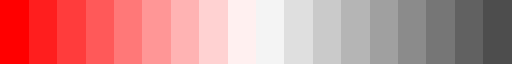

In [84]:
custom_cmap

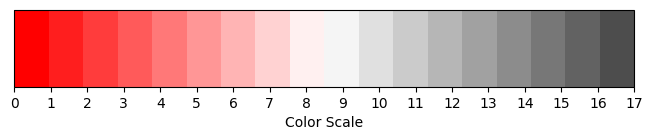

In [83]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define the starting, middle, and ending colors in RGB format
start_color = (255 / 255, 0, 0 / 255)  # RGB values for '#67001f'
mid_color = (1, 1, 1)  # RGB values for white
end_color = (77 / 255, 77 / 255, 77 / 255)  # RGB values for '#4d4d4d'

# Specify the colors in the colormap
colors = [start_color, mid_color, end_color]

# Create the colormap
n_steps = 18
cmap_name = 'custom_diverging_colormap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_steps)

# Create a colorbar to visualize the colormap
fig, ax = plt.subplots(figsize=(8, 1))
bounds = [i / (n_steps - 1) for i in range(n_steps)]
ticks = [f'{i}' for i in range(n_steps)]
cb = plt.colorbar(plt.cm.ScalarMappable(cmap=custom_cmap), cax=ax, orientation='horizontal', ticks=bounds)
cb.set_label('Color Scale')
cb.set_ticklabels(ticks)

# Show the colorbar
plt.show()


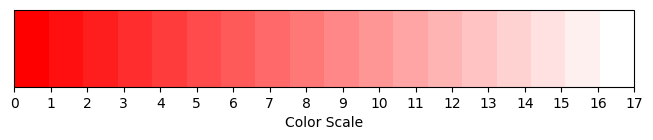

In [58]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define the starting and ending colors in RGB format
start_color = (255 / 255, 0, 0 / 255)  # RGB values for '#800026'
end_color = (1, 1, 1)  # RGB values for '#ffffff'

# Specify the colors in the colormap
colors = [start_color, end_color]

# Create the colormap
n_steps = 18
cmap_name = 'custom_colormap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_steps)

# Create a colorbar to visualize the colormap
fig, ax = plt.subplots(figsize=(8, 1))
bounds = [i / (n_steps - 1) for i in range(n_steps)]
ticks = [f'{i}' for i in range(n_steps)]
cb = plt.colorbar(plt.cm.ScalarMappable(cmap=custom_cmap), cax=ax, orientation='horizontal', ticks=bounds)
cb.set_label('Color Scale')
cb.set_ticklabels(ticks)

# Show the colorbar
plt.show()
